# 第 8 天：GPT Planner 与动作验证

让 LLM 提出实验动作，再用 ChemWorld validator 检查、修复和回放。

今天把 GPT 当作 planner，而不是无约束答案生成器：它必须输出结构化动作，并接受 validator 与 replay 的约束。


## 学习路径定位

| 项目 | 内容 |
| --- | --- |
| 阶段 | C. 形成项目 |
| 难度 | 挑战 1/4 |
| 先修 | 理解 operation schema、task policy 和前置条件。 |
| 今天只解决 | 把 GPT-style proposal 转成可验证、可修复、可执行的实验 recipe。 |
| 今天不要求 | 不依赖在线 GPT API；重点是 planner 输出必须受 schema 和 validator 约束。 |
| 本日交付 | 原始 plan、validator 反馈、修复后的 action sequence。 |
| 下一步如何复用 | Day 9 会把自动规划与 BO/safe BO 的闭环选点连接起来。 |



## 课堂时间盒：每 30 分钟都有产出

建议按 3 小时工作坊使用。每一段都要留下一个小证据，不要只运行代码看到结果就继续往下翻。

| 时间 | 阶段目标 | 具体动作 | 当段产出 |
| --- | --- | --- | --- |
| 0:00-0:30 | 把 GPT 当 planner | 把自然语言计划改写成结构化 action。 | 得到候选动作列表。 |
| 0:30-1:00 | schema 检查 | 运行 validate_action_schema 或 validate_recipe。 | 找出格式错误。 |
| 1:00-1:30 | 物理前置检查 | 用 validator 检查状态依赖和 task policy。 | 找出不可执行动作。 |
| 1:30-2:00 | 修复计划 | 修改操作顺序、payload 或 instrument。 | 得到可执行 recipe。 |
| 2:00-2:30 | 执行并记录 | 运行修复后的计划。 | 保存轨迹和失败/成功说明。 |
| 2:30-3:00 | 反思 LLM 使用 | 区分 GPT 的提议能力和验证器的约束能力。 | 写一条 agent 设计原则。 |

教师提示：如果课堂时间少于 3 小时，可以把最后两个时间盒改成课后提交；但前四个时间盒建议现场完成。


## 本日任务梯度

| 层级 | 任务 |
| --- | --- |
| 基础任务 | 验证一个 GPT-style action，读懂 invalid reason。 |
| 进阶任务 | 修复一个非法 recipe，使其能在环境中执行。 |
| 挑战任务 | 设计一个 tool-using planner 流程：先查询 task_info，再 validate，再执行。 |
| 反思问题 | LLM 生成的“看起来合理”的实验，为什么仍必须经过 validator？ |



## 三小时实验工单（必须自己完成）

这一节不是演示输出，而是当天真正的工作量。请不要只从上到下运行已有单元；必须在后面的学生工作区新增自己的实验、图表、表格和文字结论。

| 序号 | 最小完成量 |
| --- | --- |
| 1 | 至少写 3 个 GPT-style plan：保守、激进、安全约束三种风格。 |
| 2 | 每个 plan 至少包含 8 个 operation，并全部经过 validate/repair。 |
| 3 | 记录每次 invalid reason 和修复动作，形成 tool-call 日志表。 |
| 4 | 写 400 字讨论：LLM planner 在哪里帮了忙，在哪里必须被工具约束。 |

验收口径：本日交付至少应包含数据表、图或谱图、验证/评测结果、机制解释和下一步实验建议。低于这些证据量，视为只完成了演示浏览。



## 学生工作区

请从这里开始写自己的实验扩展。建议保留上方演示单元作为参考，不要直接覆盖；把你新增的实验条件、图、模型、验证结果和文字结论放在下面。

建议你在本节下面新增自己的代码单元。可从这个记录模板开始：

```python
student_work = {
    "hypothesis": "",
    "experiments_added": 0,
    "figures_created": 0,
    "verification_or_metric": "",
    "next_experiment": "",
}
```



In [1]:
import importlib
import sys
from pathlib import Path

import pandas as pd
from IPython.display import display

ROOT = Path.cwd()
while not (ROOT / "pyproject.toml").exists() and ROOT.parent != ROOT:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "notebooks" / "tutorials"))

tu = importlib.import_module("tutorial_utils")

pd.set_option("display.precision", 4)
OUTPUT_DIR = tu.ensure_output(8)
print("project root:", ROOT)
print("output dir:", OUTPUT_DIR)

project root: D:\Projects\ChemWorld
output dir: D:\Projects\ChemWorld\runs\tutorials\day08


## 今日任务

请先运行顶部导入单元，确认 kernel 指向项目虚拟环境；随后按顺序执行每个代码单元，观察表格、图形和验证结果，并在最后写下自己的实验判断。


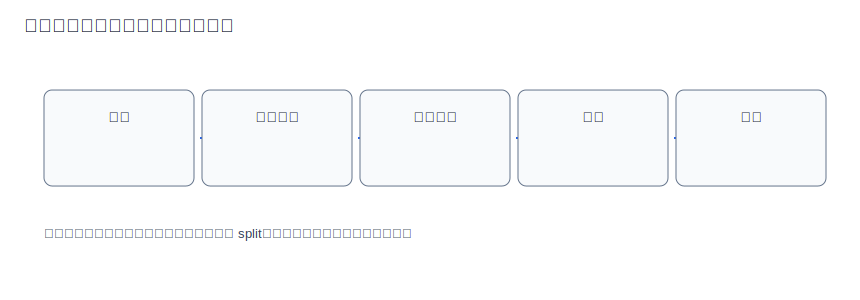

In [2]:
tu.display_tutorial_header(
    day=8,
    title='GPT Planner 与动作验证',
    subtitle='让 LLM 提出实验动作，再用 ChemWorld validator 检查、修复和回放。',
    focus=[
        '严格 JSON proposal',
        'ActionCodec',
        'OperationValidator',
        '修复循环',
    ],
    deliverables=[
        '一组合法 action list',
        '一个被拒绝或修复的 proposal',
        '一条 GPT 约束说明',
    ],
    project_link='LLM agent 的可信度来自 prompt、validator、缓存、成本和 replay 记录。',
)
tu.display_course_map(8)
display(tu.world_law_svg())


In [3]:
tu.display_api_card()

## 第 8 天检查点

完成本 notebook 后，请确认你已经留下这些证据：

- 一组通过 validator 的 JSON 动作
- 一个被拒绝或修复的 proposal
- 一张 proposal 分数柱状图
- 一条 GPT 受约束方式说明


In [5]:
gpt_prompt = {
    "system": "You propose virtual ChemWorld reaction experiments as strict JSON only.",
    "task": "Suggest five recipes that balance yield, safety risk, and degradation.",
    "schema": {
        "temperature": "degC in [40, 160]",
        "time": "h in [0.25, 8.0]",
        "initial_concentration": "mol/L in [0.10, 2.00]",
        "stirring_speed": "rpm in [100, 1200]",
        "catalyst": "integer 0..3",
        "solvent": "integer 0..3",
        "rationale": "short chemical reason",
    },
}
tu.show_json_panel("GPT planner prompt contract", gpt_prompt)

In [6]:
from chemworld.core.actions import canonicalize_action

raw_gpt_proposals = [
    {
        "temperature": 72,
        "time": 0.55,
        "initial_concentration": 0.32,
        "stirring_speed": 650,
        "catalyst": 1,
        "solvent": 1,
        "rationale": "moderate heat with lower risk solvent",
    },
    {
        "temperature": 95,
        "time": 0.40,
        "initial_concentration": 0.42,
        "stirring_speed": 760,
        "catalyst": 1,
        "solvent": 2,
        "rationale": "faster target reaction, watch degradation",
    },
    {
        "temperature": 145,
        "time": 0.90,
        "initial_concentration": 0.90,
        "stirring_speed": 1300,
        "catalyst": 7,
        "solvent": 3,
        "rationale": "invalid stress test from an overconfident planner",
    },
    {
        "temperature": 58,
        "time": 0.85,
        "initial_concentration": 0.28,
        "stirring_speed": 550,
        "catalyst": 0,
        "solvent": 0,
        "rationale": "slow safer run to test degradation",
    },
    {
        "temperature": 105,
        "time": 0.25,
        "initial_concentration": 0.50,
        "stirring_speed": 820,
        "catalyst": 3,
        "solvent": 1,
        "rationale": "short hot run to trade conversion against degradation",
    },
]

validated = []
for proposal_id, proposal in enumerate(raw_gpt_proposals, start=1):
    action = {key: value for key, value in proposal.items() if key != "rationale"}
    fixed = canonicalize_action(action)
    validated.append(
        {
            "proposal": f"p{proposal_id}",
            "recipe": fixed,
            **tu.format_recipe(fixed),
            "changed_by_validator": fixed != action,
            "rationale": proposal["rationale"],
        }
    )
validated_df = pd.DataFrame(validated)
cols = [
    "proposal",
    "temperature_C",
    "time_h",
    "initial_concentration_M",
    "catalyst",
    "solvent",
    "changed_by_validator",
    "rationale",
]
display(validated_df[cols])

,proposal,temperature_C,time_h,initial_concentration_M,catalyst,solvent,changed_by_validator,rationale
0,p1,72.0,0.55,0.32,cat_b,ethanol,False,moderate heat with lower risk solvent
1,p2,95.0,0.40,0.42,cat_b,acetonitrile,False,"faster target reaction, watch degradation"
2,p3,145.0,0.90,0.90,cat_d,toluene,True,invalid stress test from an overconfident planner
3,p4,58.0,0.85,0.28,cat_a,water,False,slow safer run to test degradation
4,p5,105.0,0.25,0.50,cat_d,ethanol,False,short hot run to trade conversion against degr...


,proposal,yield,degradation,risk,score,changed_by_validator,rationale
0,p2,0.6263,0.2384,0.1228,0.4811,False,"faster target reaction, watch degradation"
1,p1,0.6072,0.1462,0.0811,0.4805,False,moderate heat with lower risk solvent
2,p4,0.5382,0.0336,0.0518,0.4595,False,slow safer run to test degradation
3,p5,0.3710,0.1819,0.1312,0.2846,False,short hot run to trade conversion against degr...
4,p3,0.0007,0.5500,0.4224,0.0000,True,invalid stress test from an overconfident planner


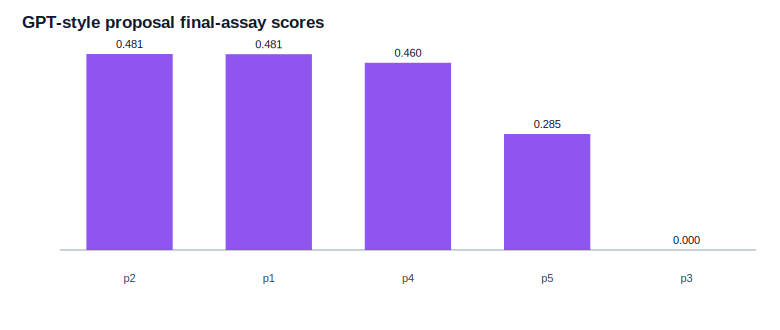

In [7]:
results = []
for row in validated:
    result = tu.run_recipe(row["recipe"], split="public-test", seed=810)
    result["proposal"] = row["proposal"]
    result["changed_by_validator"] = row["changed_by_validator"]
    result["rationale"] = row["rationale"]
    results.append(result)
result_df = pd.DataFrame(results).sort_values("score", ascending=False).reset_index(drop=True)
display(
    result_df[
        ["proposal", "yield", "degradation", "risk", "score", "changed_by_validator", "rationale"]
    ]
)
display(
    tu.bar_svg(
        result_df["proposal"].tolist(),
        result_df["score"].astype(float).tolist(),
        title="GPT-style proposal final-assay scores",
        color="#7c3aed",
    )
)

In [8]:
best = result_df.iloc[0]
feedback_prompt = {
    "observed_best": {
        "proposal": best["proposal"],
        "score": float(best["score"]),
        "yield": float(best["yield"]),
        "risk": float(best["risk"]),
    },
    "instruction": (
        "Propose three local variations near the best condition, but reduce risk and degradation."
    ),
    "guardrail": "All outputs must pass canonicalize_action before execution.",
}
tu.show_json_panel("Feedback prompt for a next GPT planning round", feedback_prompt)

## 课后反思

请用两三句话回答下面的问题，并把答案写进当天的实验日志。


In [9]:
tu.display_reflection_box(
    [
        '哪类自然语言计划最容易变成非法动作？',
        'validator 应该怎样约束 LLM 的自由发挥？',
    ]
)
